https://rbrooksdk.github.io/STA1_26/assignments/assignment_02_discrete_and_continuous_models/

In [1]:
from IPython.display import display, Markdown
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

# Part 1 — Cooling-unit failures: a finite random variable
## Let $X$ be the number of cooling units that fail during a weekly maintenance window. The engineering model is

|      $x$ |    0 |    1 |    2 |    3 |    4 |
| -------: | ---: | ---: | ---: | ---: | ---: |
| $P(X=x)$ | 0.58 | 0.26 | 0.10 | 0.04 | 0.02 |


### a) Verify that the table is a valid PMF, state the support, and distinguish the random variable $X$ from an observed value $x$ .

The sum of all P(X = x) values is 1 and all values are >= 0 so the table is a valid PMF.

support(X) = {0, 1, 2, 3, 4}

X is the number of cooling units that will fail this week and x is the placeholder used to ask questions about X.

### b) Construct a table containing $x$, $p_X(x)$, and $F_X(x)$. Use it to calculate $P(X=2)$, $P(X\leq1)$, $P(X\geq2)$, and $P(1<X\leq3)$.


In [42]:
x = np.array([0, 1, 2, 3, 4])
p = np.array([0.58, 0.26, 0.10, 0.04, 0.02])
F = np.cumsum(p)

table = pd.DataFrame({
    "x": x,
    "p_X(x)": p,
    "F_X(x)": F
})
print(table)

P_X_eq_2   = table.loc[table["x"] == 2, "p_X(x)"].values[0]
P_X_le_1   = table.loc[table["x"] == 1, "F_X(x)"].values[0]
P_X_ge_2   = 1 - table.loc[table["x"] == 1, "F_X(x)"].values[0]
P_1_lt_X_le_3 = (table.loc[table["x"] == 3, "F_X(x)"].values[0]
                 - table.loc[table["x"] == 1, "F_X(x)"].values[0])

print(f"P(X=2)      = {P_X_eq_2}")
print(f"P(X<=1)     = {P_X_le_1}")
print(f"P(X>=2)     = 1 - P(X<=1) = {P_X_ge_2}")
print(f"P(1<X<=3)   = {P_1_lt_X_le_3}")

   x  p_X(x)  F_X(x)
0  0    0.58    0.58
1  1    0.26    0.84
2  2    0.10    0.94
3  3    0.04    0.98
4  4    0.02    1.00
P(X=2)      = 0.1
P(X<=1)     = 0.84
P(X>=2)     = 1 - P(X<=1) = 0.16000000000000003
P(1<X<=3)   = 0.14


### c) Plot the PMF as a bar chart and the CDF as a step plot. Explain the meaning of the height at each value in both plots.

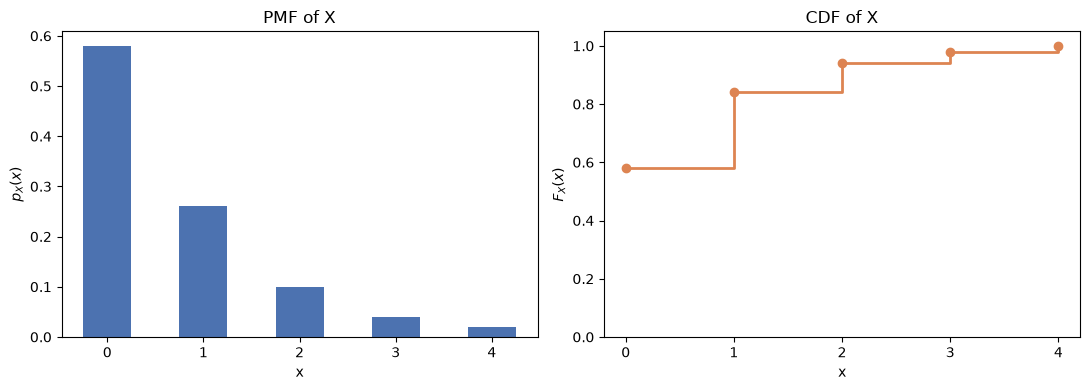

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(x, p, color="#4C72B0", width=0.5)
axes[0].set_xlabel("x")
axes[0].set_ylabel(r"$p_X(x)$")
axes[0].set_title("PMF of X")
axes[0].set_xticks(x)

axes[1].step(x, F, where="post", color="#DD8452", linewidth=2)
axes[1].scatter(x, F, color="#DD8452", zorder=3)
axes[1].set_xlabel("x")
axes[1].set_ylabel(r"$F_X(x)$")
axes[1].set_title("CDF of X")
axes[1].set_xticks(x)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In the PMF chart, the height of the bar shows the exact probability of exact that many cooling units to fail. So when x = 1, there is a 26% chance that exact 1 cooling unit will fail. Not more, not less. Exactly 1.

In the CDF, the size in each jump is the height of the corresponding PMF bar which is p_x(x). It has a staircase looking aspect because it shows the cumulative probability up to and including that point.

### d) Calculate and interpret $E[X]$, $Var(X)$, and $SD(X)$.

In [26]:
E_X = np.sum(x * p)
E_X2 = np.sum(x**2 * p)
Var_X = E_X2 - E_X**2
SD_X = np.sqrt(Var_X)
print(f"E[X] = {E_X:.4f}, Var(X) = {Var_X:.4f}, SD(X) = {SD_X:.4f}")

E[X] = 0.6600, Var(X) = 0.9044, SD(X) = 0.9510


On average, around 0.66 cooling units fail per week. 
The typical week's failure count deviates from the mean (which is 0.66) by 0.9510 units.

# Part 2 — Repeated-event count models
# Late supplier deliveries: binomial

## A project expects 30 deliveries. Each is modelled as late with probability 0.12 independently of the others. Let be the number of late deliveries.

### a) Justify $B \sim Bin(30, 0.12)$. Identify the Bernoulli trial and discuss fixed $n$, constant $p$, independence, and one realistic violation.

In [5]:
n = 30
p = 0.12



There are 30 trials, so getting the sum of 30 yes/no trials just makes it a binomial distributon

 We know that we have a fixed number of trials
 We also know that in this case we only care about late/not late giving two possible outcomes
 Deliveries are independent when it comes to the odds of being late( This is a clear violation of reality, You can argue that 12% probability is realistic, but the complete disconnect from the chain of deliveries is inaccurate, because lost time in a delivery takes away from the allocated timebox of others setting off a domino effect)
 

### b) Use SciPy to calculate $P(B=3)$, $P(B\leq4)$, and $P(B\geq5)$. For $P(B=3)$, also show the binomial formula and explain $\binom{n}{k}$. For the upper tail, explain the correct survival-function argument.


In [6]:
p_3 = stats.binom.pmf(3, n, p)

possible_outcomes = math.comb(n,3)
one_outcome = p**3 * (1-p)**(n-3)
manual_calc= possible_outcomes * one_outcome

print("how many ways to choose 3 successes from 30 trials:", possible_outcomes)
print("Probability of exactly 3 successes:", round(p_3, 4))
print("Manually calculated probability:", round(manual_calc, 4))

p_max_4 = stats.binom.cdf(4, n, p)
print("Probability of at most 4 successes:", round(p_max_4, 4))

p_min_5 = stats.binom.sf(4, n, p)
print("Probability of at least 5 successes:", round(p_min_5, 4))

#p max 4 and p min 5 should add up to 1
print(p_max_4+ p_min_5)

how many ways to choose 3 successes from 30 trials: 4060
Probability of exactly 3 successes: 0.2224
Manually calculated probability: 0.2224
Probability of at most 4 successes: 0.7118
Probability of at least 5 successes: 0.2882
1.0




$$P(B = k) = \binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}$$

$$P(B = 3) = \binom{30}{3} \cdot 0.12^3 \cdot 0.88^{27}$$

$\binom{30}{3}$ is the number of ways to choose 3 of 30 when order is irellevant
so we do combinations of 30 taken by 3 and we get 30x29x28/3x2x1 = 4060

B<=4 uses cdf which handles the sum of the 0 1 2 3 4 late deliveries 
B>=5 uses sf(4) not 5, because sf handles the strictly larger than passed argument. 

### c) Calculate and interpret the mean and standard deviation.

In [7]:
B = stats.binom(n, p)
mean_B = B.mean()

sd_B = B.std()

print("Mean:", round(mean_B, 2))
print("Standard deviation:", round(sd_B, 2))


Mean: 3.6
Standard deviation: 1.78


mean is 3.6 
 This means if we repeated many projects with 30 deliveries, on average 3.6 of them would be late. A single project can't have exactly 3.6 late deliveries

 standard deviation being 1.78 points us towards the fact that typically there are 2 to 5 late deliveries over each iteration.

# Production stoppages: Poisson

## Short stoppages are modelled as a Poisson process with mean 1.6 per 8-hour shift. Let be the count during one shift.

### a) State the model, parameter, support, mean, and variance. Calculate $P(Y=0)$ and $P(Y \geq 3)$ for one shift.

In [8]:
var = 1.6

Y = stats.poisson(var)

print("Mean:", Y.mean())
print("Variance:", Y.var())

zero_stoppages = Y.pmf(0)
print("P(Y = 0):", round(zero_stoppages, 4))

at_least_3 = Y.sf(2)
print("P(Y >= 3):", round(at_least_3, 4))

Mean: 1.6
Variance: 1.6
P(Y = 0): 0.2019
P(Y >= 3): 0.2166


Instead of having a fixed number of samples we take the frequency at which they occur withing a known timeframe and frequency, 

mean and variance are the same in poisson distributions.
Y=0 - one in 5 shifts has no stoppages at all
y >= 3 - 1 in 5 shifts has 3 or more stoppages, we use sf2 for the same reason as the binomial part. 

### b) Scale the expected count and calculate the probability of at least three stoppages in 24 hours. Discuss the stable-rate and independent-event assumptions.

In [9]:
var_24 = var * 3
print("Average stoppages in 24 hours:", round(var_24, 2))

Y_24 = stats.poisson(var_24)
p_24_at_least_3 = Y_24.sf(2)
print("P(Y >= 3) in 24 hours:", round(p_24_at_least_3, 4))



Average stoppages in 24 hours: 4.8
P(Y >= 3) in 24 hours: 0.8575


we can see that the average grows proportionally to the length of time. 
1.6 x (24/8) = 4.8

We assume the average is 1.6 in every shift, day or night. So multiplying by 3 makes sense. It could be wrong if, for example, the night shift has fewer workers and/or more stoppages, or if machines stop more often right after starting up.

We assume one stoppage doesn't cause another and the item gracefully continues. It could be wrong if a faulty part or bad material causes the machine to stop again and again. Then stoppages would come in groups, and very bad days would happen more often than the model predicts.

# Part 3 — Uniform and normal models
# Sensor polling delay: uniform

## A monitoring device polls a sensor once every 12 seconds. An event is assumed to occur at a random point in the cycle, so the delay $D$ until the next poll is modelled as $D \sim Uniform(0, 12)$ .

### a) Create the SciPy model using the correct location and scale. Plot its PDF and CDF and explain the support, constant density, and why $P(D=d) = 0$.

Support = (np.float64(0.0), np.float64(12.0))


Text(0.5, 1.0, 'CDF')

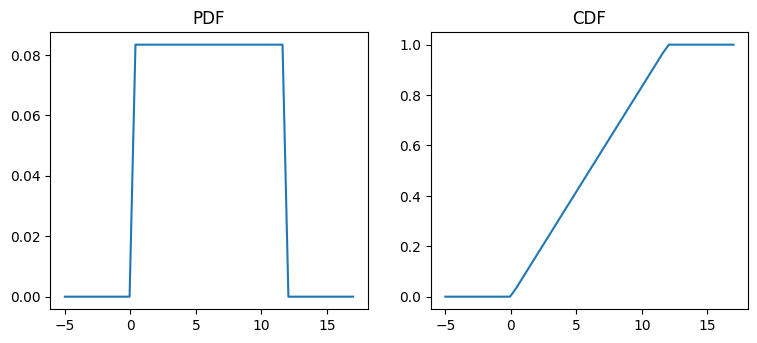

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

D = stats.uniform(loc=0, scale=12)

print(f"Support = {D.support()}")

xs = np.linspace(-5, 17)

axes[0].plot(xs, D.pdf(xs))
axes[0].set_title("PDF")
axes[1].plot(xs, D.cdf(xs))
axes[1].set_title("CDF")

1. Support is 0 to 12, since that is the provided range.
2. PDF is constant because the probability is uniform, so it's equal across the whole support
3. $P(D=d) = 0$ because time is continous and as such when trying to calculate the probability of exactly $t$ we get $ \int_t^t \frac{1}{12} = 0$

### b) Calculate $P(D \leq 3)$, $P(4 \leq D \leq 9)$, $P(D \geq 10)$, the mean, standard deviation, and 95th percentile.

In [11]:
a = D.cdf(3)
b = D.cdf(9) - D.cdf(4)
c = 1 - D.cdf(10)
mean = D.mean()
sd = D.std()
nfth = D.ppf(0.95)

display(Markdown(f"""
$P(D \\leq 3) = {a}$

$P(4 \\leq D \\leq 9) = {b}$,

$P(D \\geq 10) = {c}$

Mean = {mean}

Standard deviation = {sd}

95th percentile = {nfth}
"""))


$P(D \leq 3) = 0.25$

$P(4 \leq D \leq 9) = 0.4166666666666667$,

$P(D \geq 10) = 0.16666666666666663$

Mean = 6.0

Standard deviation = 3.4641016151377544

95th percentile = 11.399999999999999


# Concrete strength: normal working model

## The file assignment02_concrete_strength.csv contains 160 compressive-strength measurements. Treat the generating parameters as unknown.

In [12]:
cs_df = pd.read_csv("./assignment02_concrete_strength.csv")

### a) Report $n$, mean, median, and sample standard deviation. Fit $N(\hat{\mu}, \hat{\sigma}^2)$ and explain why SciPy receives $\hat{\sigma}$, not $\hat{\sigma}^2$, as `scale`.


In [13]:
[n, mean, std] = cs_df['strength_mpa'].describe()[['count', 'mean', 'std']]
median = cs_df['strength_mpa'].median()
print(f"n \t\t\t{n}")
print(f"mean \t\t\t{mean}")
print(f"median \t\t\t{median}")
print(f"standard deviation \t{std}")

N = stats.norm(loc=mean, scale=std)
print("\nSciPy receives standard deviation instead of variance since that is how it was programmed? Feasiably because it's easier to program")

n 			160.0
mean 			42.494187499999995
median 			42.379999999999995
standard deviation 	4.3429126058130105

SciPy receives standard deviation instead of variance since that is how it was programmed? Feasiably because it's easier to program


### b) Plot a density histogram with the fitted PDF and create a normal QQ-plot. Discuss symmetry, tails, unusual observations, and model adequacy.

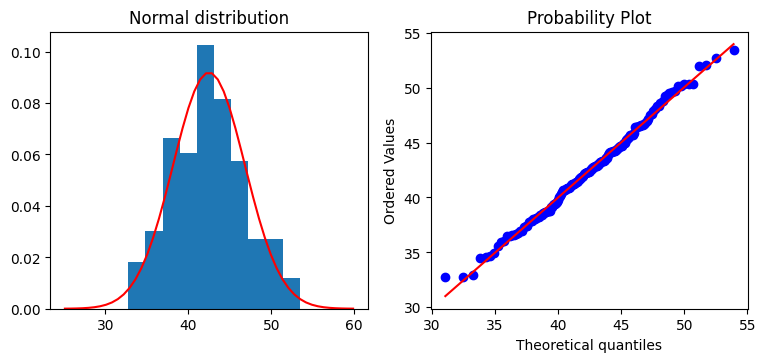


#### Altogether the normal distribution seems to represent the data well, the only surprise is the 41-42 bucket which is noticably bigger in the actual data, and 40-41 which is noticably smaller. 
#### We can further see the adequacy on the QQ graph which aligns well. 
#### The data gathered seems symmetrical around the well pronounced 41-42 bucket and has no noticable tails.

In [14]:
xs = np.linspace(mean - 4*std, mean + 4*std)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

axes[0].set_title("Normal distribution")
axes[0].plot(xs, N.pdf(xs), color="red", label="Normal PDF")
axes[0].hist(cs_df['strength_mpa'], density=True)

axes[1].set_title("QQ-plot")
stats.probplot(cs_df['strength_mpa'], dist=N, plot=axes[1])

plt.show()
display(Markdown("""
#### Altogether the normal distribution seems to represent the data well, the only surprise is the 41-42 bucket which is noticably bigger in the actual data, and 40-41 which is noticably smaller. 
#### We can further see the adequacy on the QQ graph which aligns well. 
#### The data gathered seems symmetrical around the well pronounced 41-42 bucket and has no noticable tails."""))

### c) From the fitted model, calculate $P(X < 35)$, $P(38 < X < 46)$, the 95th percentile, and the $z$-score of 35 MPa. Compare the first two model probabilities with empirical proportions.

In [15]:
a = N.cdf(35)
b = N.cdf(46) - N.cdf(38)
nfth = N.ppf(0.95)

zScore = (35 - mean) / std

display(Markdown(f"""
$P(X < 35) = {a}$

$P(38 < X < 46) = {b}$

$95th$ percentile = ${nfth}$

$z$-score at 35MPa = ${zScore}$

"""))


$P(X < 35) = 0.04220850775780511$

$P(38 < X < 46) = 0.639864972318845$

$95th$ percentile = $49.6376430512048$

$z$-score at 35MPa = $-1.725613241668503$



In [16]:
## Empirical comparison:
mpa = cs_df['strength_mpa']
ptf = mpa.loc[mpa < 35].count() / mpa.count()
ptefs = mpa.loc[mpa > 38].loc[mpa < 46].count() / mpa.count()

display(Markdown(f"""
$P(X < 35) = {ptf}$

$P(38 < X < 46) = {ptefs}$

### The differences between probabilities calculated from the fitted normal distribution and the actual data:

${ptf} - {a} = {ptf - a}$

${ptefs} - {b} = {ptefs - b}$

### the differences are not significant, 0.1% and 0.2%
"""))


$P(X < 35) = 0.04375$

$P(38 < X < 46) = 0.6375$

### The differences between probabilities calculated from the fitted normal distribution and the actual data:

$0.04375 - 0.04220850775780511 = 0.0015414922421948876$

$0.6375 - 0.639864972318845 = -0.0023649723188450267$

### the differences are not significant, 0.1% and 0.2%


# Part 4 — Service restoration: an exponential working model

## The file assignment02_service_repairs.csv contains 180 restoration times from independent service incidents. Treat the rate as unknown.

### a) Report $n$, mean, median, sample standard deviation, minimum, and maximum. Plot a density histogram and describe the shape.

In [17]:
sr_df = pd.read_csv("./assignment02_service_repairs.csv")
T_data = sr_df['repair_time_min']

n = T_data.count()
mean = T_data.mean()
median = T_data.median()
std = T_data.std()
t_min = T_data.min()
t_max = T_data.max()

print(f"n \t\t\t{n}")
print(f"mean \t\t\t{mean}")
print(f"median \t\t\t{median}")
print(f"standard deviation \t{std}")
print(f"minimum \t\t{t_min}")
print(f"maximum \t\t{t_max}")

n 			180
mean 			69.79861111111111
median 			49.345
standard deviation 	67.43318667051601
minimum 		1.11
maximum 		410.66


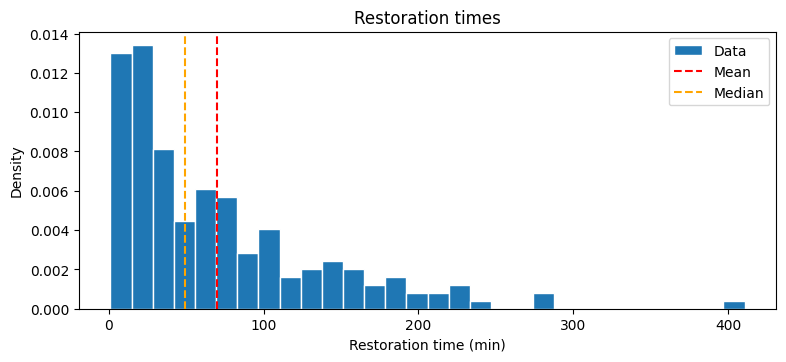

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.6))

ax.set_title("Restoration times")
ax.hist(T_data, bins=30, density=True, edgecolor="white", label="Data")
ax.axvline(mean, color="red", linestyle="--", label="Mean")
ax.axvline(median, color="orange", linestyle="--", label="Median")
ax.set_xlabel("Restoration time (min)")
ax.set_ylabel("Density")
ax.legend()

plt.show()

Strongly right-skewed: peak near 0, steep drop, then a long tail up to ≈ 410 min.
- Mean (69.8) > median (49.3) confirms the right skew. Half of incidents are restored within ≈ 49 min.
- Mean ≈ SD (69.8 vs 67.4), which matches $E[T] = SD(T) = 1/\lambda$ for an exponential.

### b) Fit an exponential model using $\hat{\lambda} = 1/\bar{x}$. State its fitted rate, mean, variance, and SciPy scale and add the fitted PDF to the histogram.


Fitted rate $\hat{\lambda} = 0.01433$ per minute

Mean $= 1/\hat{\lambda} = 69.80$ min

Variance $= 1/\hat{\lambda}^2 = 4871.85$ min²

SciPy `scale` $= 1/\hat{\lambda} = 69.80$ min, `loc` $= 0$


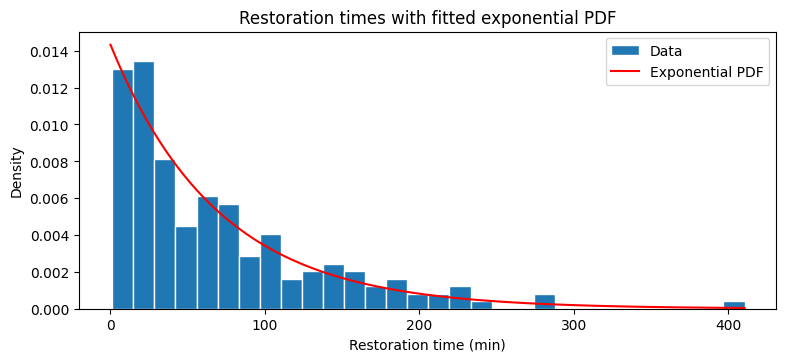

In [19]:
lam_hat = 1 / mean
E = stats.expon(loc=0, scale=1/lam_hat)

display(Markdown(f"""
Fitted rate $\\hat{{\\lambda}} = {lam_hat:.5f}$ per minute

Mean $= 1/\\hat{{\\lambda}} = {E.mean():.2f}$ min

Variance $= 1/\\hat{{\\lambda}}^2 = {E.var():.2f}$ min²

SciPy `scale` $= 1/\\hat{{\\lambda}} = {E.kwds['scale']:.2f}$ min, `loc` $= 0$
"""))

xs = np.linspace(0, t_max, 400)

fig, ax = plt.subplots(figsize=(9, 3.6))

ax.set_title("Restoration times with fitted exponential PDF")
ax.hist(T_data, bins=30, density=True, edgecolor="white", label="Data")
ax.plot(xs, E.pdf(xs), color="red", label="Exponential PDF")
ax.set_xlabel("Restoration time (min)")
ax.set_ylabel("Density")
ax.legend()

plt.show()

### c) Compare empirical and fitted distributions using an empirical CDF with fitted CDF or an exponential QQ-plot. Discuss model strengths and limitations.

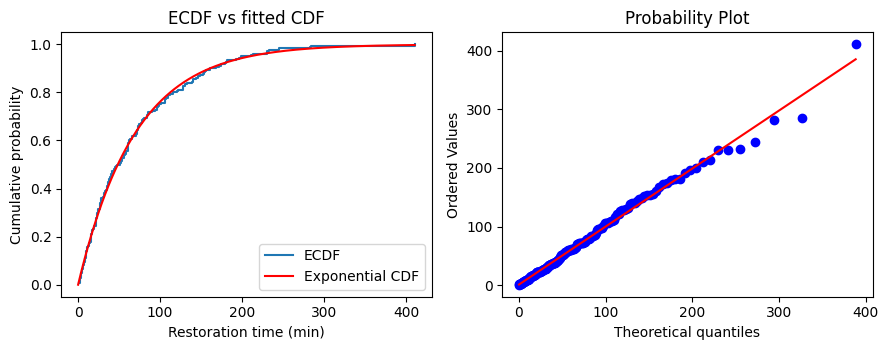

In [20]:
t_sorted = np.sort(T_data)
ecdf = np.arange(1, n + 1) / n

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

axes[0].set_title("ECDF vs fitted CDF")
axes[0].step(t_sorted, ecdf, where="post", label="ECDF")
axes[0].plot(xs, E.cdf(xs), color="red", label="Exponential CDF")
axes[0].set_xlabel("Restoration time (min)")
axes[0].set_ylabel("Cumulative probability")
axes[0].legend()

axes[1].set_title("Exponential QQ-plot")
stats.probplot(T_data, dist=E, plot=axes[1])

plt.tight_layout()
plt.show()

**Strengths:** ECDF and fitted CDF almost overlap (max gap ≈ 0.03), and the QQ-plot follows the line up to ≈ 220 min. Correct support $[0, \infty)$.

**Limitations:**
- The largest values fall slightly below the QQ line, so the tail is a bit lighter than the model's.
- There is only one parameter, so the spread is fixed by the mean (model var ≈ 4872 vs sample ≈ 4547).
- The tail rests on few observations.
- A constant repair rate is unlikely for a mix of simple and complex incidents.

### d) Calculate and interpret $P(T \leq 30)$, $P(T > 120)$, the median, and the 90th percentile. Compare the two model probabilities with empirical proportions.

In [21]:
a = E.cdf(30)
b = E.sf(120)
t_median = E.ppf(0.5)
t_90 = E.ppf(0.9)

## Empirical proportions
emp_a = (T_data <= 30).mean()
emp_b = (T_data > 120).mean()

display(Markdown(f"""
$P(T \\leq 30) = {a:.4f}$

$P(T > 120) = {b:.4f}$

Median $= \\ln(2)/\\hat{{\\lambda}} = {t_median:.2f}$ min

90th percentile $= {t_90:.2f}$ min

### Model vs empirical proportions:

| | Model | Empirical | Difference |
|---|---|---|---|
| $P(T \\leq 30)$ | {a:.4f} | {emp_a:.4f} | {emp_a - a:.4f} |
| $P(T > 120)$ | {b:.4f} | {emp_b:.4f} | {emp_b - b:.4f} |
"""))


$P(T \leq 30) = 0.3494$

$P(T > 120) = 0.1792$

Median $= \ln(2)/\hat{\lambda} = 48.38$ min

90th percentile $= 160.72$ min

### Model vs empirical proportions:

| | Model | Empirical | Difference |
|---|---|---|---|
| $P(T \leq 30)$ | 0.3494 | 0.3611 | 0.0117 |
| $P(T > 120)$ | 0.1792 | 0.2000 | 0.0208 |


- $P(T \leq 30) \approx 0.35$: 35% of incidents are restored within 30 min.
- $P(T > 120) \approx 0.18$: 18% take longer than 2 hours.
- Median ≈ 48.4 min (= $\ln 2/\hat\lambda$): half are restored within ≈ 48 min.
- 90th percentile ≈ 160.7 min: 90% are restored within ≈ 2 h 40 min.

Empirical proportions are close: 0.361 vs 0.349 and 0.200 vs 0.179. The model slightly underestimates long repairs around 120 min (≈ 4 incidents).

### e) Calculate $P(T > 150 \mid T > 60)$ as both a ratio of survival probabilities and the probability of waiting an additional 90 minutes. Explain the memoryless and constant-rate assumptions.

In [22]:
cond = E.sf(150) / E.sf(60)

extra = E.sf(90)

n_60 = (T_data > 60).sum()
n_150 = (T_data > 150).sum()
emp_cond = n_150 / n_60

display(Markdown(f"""
$P(T > 150 \\mid T > 60) = \\dfrac{{P(T > 150)}}{{P(T > 60)}} = \\dfrac{{{E.sf(150):.4f}}}{{{E.sf(60):.4f}}} = {cond:.4f}$

$P(T > 90) = e^{{-90\\hat{{\\lambda}}}} = {extra:.4f}$

Empirical: {n_150} of the {n_60} incidents lasting over 60 min also lasted over 150 min, i.e. ${emp_cond:.4f}$
"""))


$P(T > 150 \mid T > 60) = \dfrac{P(T > 150)}{P(T > 60)} = \dfrac{0.1166}{0.4233} = 0.2754$

$P(T > 90) = e^{-90\hat{\lambda}} = 0.2754$

Empirical: 23 of the 80 incidents lasting over 60 min also lasted over 150 min, i.e. $0.2875$


$\{T > 150\} \cap \{T > 60\} = \{T > 150\}$, so
$$P(T > 150 \mid T > 60) = \frac{e^{-150\lambda}}{e^{-60\lambda}} = e^{-90\lambda} = P(T > 90) \approx 0.275$$

**Memoryless:** the time already spent does not change the remaining waiting time. An incident open for 60 min has the same chance of lasting 90 more minutes as a new one.

**Constant rate:** this follows from a constant $\hat\lambda \approx 0.0143$/min. It is questionable in practice (complex incidents last longer, escalation speeds things up), but the data agrees well: 23/80 = 0.288.

# Overall conclusion

## Write approximately 150–250 words comparing the probability models used in the assignment. Explain how support, mechanism, parameterisation, and graphical model assessment determine whether a calculated probability is useful.

### Only use Sessions 3–4. Do not use sampling distributions, confidence intervals, hypothesis tests, bootstrap procedures, or later methods.

Models used: finite PMF, binomial, Poisson for counts.
             uniform, normal and exponential for continuous measurements. 

PMF gives the probability of each value while PDF gives the area under the curve of two values. 

Models should output values that can happen, a model that can produce impossible values is likely to underperform when calculated. Binomial stops at 30 in our case, poisson is unbounded but it counts whole events, not partial which is fitting our case with the stoppages. I NEED HELP WITH UNIFORM AND THE OTHER 2

A point of innacuracy is the assumption that the deliveries are independent, that night shifts might interfere with the stoppage rate and low probablility high impact can definetly squeue the repair rate. 

What else? I am lost

AI USAGE:

General questions regarding theory and fact checking personal knowledge. Markdown formatting, and code checks, debugging. Tools used Claude and whatever autocomplete VSCode has enabled now. 